In [1]:
import numpy as np

In [169]:
class OLogisticRegression:
    def __init__(self,iter,alp):
        self.iter=iter
        self.alp=alp
    def std_inner_prod(self,a,b):
        '''
        a is X and b is theta
        '''
        return np.matmul(b,a.T)
    def sigmoid_func(self,X,theta):
        eps=np.random.normal(0,0.01)
        return 1/(1+np.exp(-self.std_inner_prod(X,theta)))
    def fit(self,X,y):
        theta=np.zeros(shape=X.shape[1])
        X=np.array(X)
        y=np.array(y)
        ones=np.ones((X.shape[0],1))
        np.hstack([ones,X])
        for t in range(0,self.iter,1):
            h=self.sigmoid_func(X,theta)
            theta_copy=theta.copy()
            for j in range(0,X.shape[1],1):
                theta_copy[j]=theta_copy[j]-(1/X.shape[0])*self.alp*(np.sum((h-y)*(X[:,j])))
            theta=theta_copy
        self.theta=theta
        self.coef_=self.theta[1:]
        self.intercept_=self.theta[0]
        return 'Model was fitted'
    def predict(self,X_pred):
        return self.sigmoid_func(X_pred,self.theta)
    

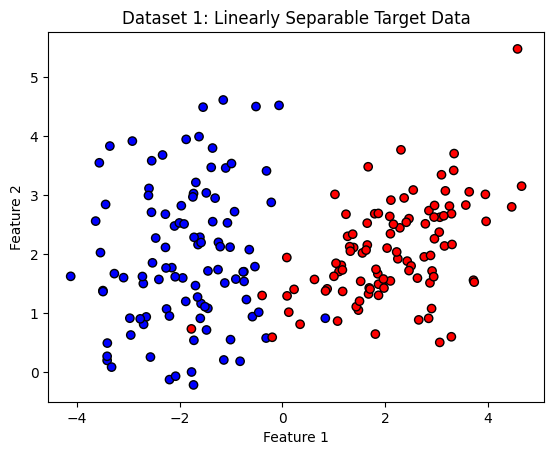

X_train shape: (160, 2)
y_train shape: (160,)


In [170]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# 1. Generate clean, linearly separable data
X, y = make_classification(
    n_samples=200, 
    n_features=2, 
    n_informative=2, 
    n_redundant=0, 
    n_clusters_per_class=1, 
    class_sep=2.0,      # Pushes clusters far apart making it easy
    random_state=42
)

# 2. Split into Train and Test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Visual check (Your math brain needs to see the separation)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k')
plt.title("Dataset 1: Linearly Separable Target Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Print shapes to verify your matrix dimensions
print(f"X_train shape: {X_train.shape}")  # Should be (160, 2)
print(f"y_train shape: {y_train.shape}")  # Should be (160,)

In [171]:
olr=OLogisticRegression(100,0.1)

In [172]:
olr.fit(X,y)

'Model was fitted'

In [173]:
olr.predict(np.array([0.1,-0.1]))

np.float64(0.5456284706743936)

In [174]:
olr.coef_

array([-0.11317906])

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 100 is different from 2)

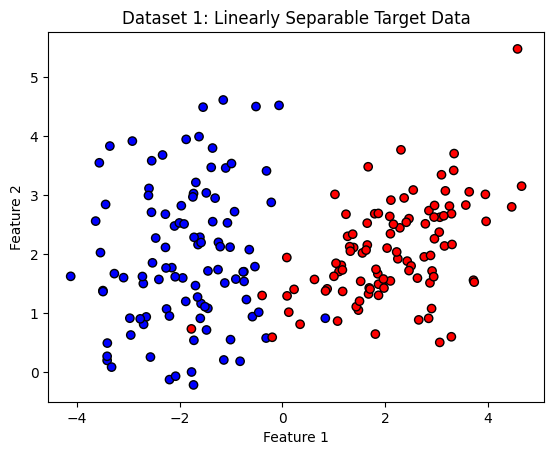

In [175]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k')
plt.title("Dataset 1: Linearly Separable Target Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

xx,yy=np.linspace(X[:,0].min(),X[:,0].max()),np.linspace(X[:,1].min(),X[:,1].max())
grid=np.meshgrid([xx.ravel(),yy.ravel()])
Z_prob = olr.predict(grid[0])
plt.contourf(xx,yy,Z_prob)

plt.contour()
plt.show()

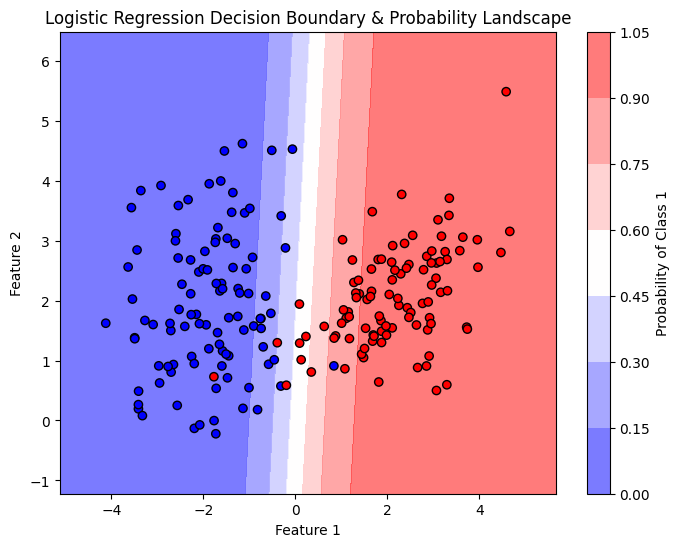

In [176]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Create independent 1D arrays for your axis ranges
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200)

# 2. Correctly generate the 2D mesh grids
# xx_grid and yy_grid will both have a shape of (200, 200)
xx_grid, yy_grid = np.meshgrid(xx, yy)

# 3. Flatten grids and stack them to create coordinate pairs for prediction
# This creates a matrix of shape (40000, 2) that your model expects
grid_coordinates = np.column_stack([xx_grid.ravel(), yy_grid.ravel()])

# 4. Predict probabilities and reshape the output back into a 2D grid
# Z_prob must be reshaped to match the (200, 200) shape of the grid
Z_prob = olr.predict(grid_coordinates)
Z_prob = Z_prob.reshape(xx_grid.shape)

# 5. Plot the colored filled contours
plt.figure(figsize=(8, 6))
contour = plt.contourf(xx_grid, yy_grid, Z_prob, cmap='bwr', alpha=0.6)
plt.colorbar(contour, label='Probability of Class 1')

# 6. Overlay your original dataset scatter points on top
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k', linewidth=1)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Logistic Regression Decision Boundary & Probability Landscape")
plt.show()